<a href="https://colab.research.google.com/github/roshansadath/COMP6721-AppliedAI/blob/main/Hyperparameter%20Tuning/AlexNet_Harvard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
import os, time, random, torch, warnings
import numpy as np
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings("ignore", category=UserWarning)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
data_path = "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI-Driven Diagnostics Medical Imaging Models Convolutional Neural Networks (CNNs) /Medical-Image-Diagnosis-using-Convolutional-Neural-Networks-main/Hyperparameter Tuning/Harvard_Chest_XRay/"
#data_path = "drive/My Drive/NIH_Chest_XRay/"
#data_path = "drive/My Drive/Simple_Chest_XRay/"

sample_ratio = 0.4
batch_size = 128
num_epochs = 15

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
def save_metrics(loss, accuracy, model):
  np.save("{}{}_train_loss.npy".format(data_path, model), loss)
  np.save("{}{}_train_accuracy.npy".format(data_path, model), accuracy)

**DATA PREPROCESSING**

In [6]:
%run "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI-Driven Diagnostics Medical Imaging Models Convolutional Neural Networks (CNNs) /Medical-Image-Diagnosis-using-Convolutional-Neural-Networks-main/utils.ipynb"

# Define data_transforms before using it
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize image channels
])

def data_preprocess(data_path, sample_ratio):
  # ... (other parts of the function) ...

  # Get dataset from folder and apply data transforms
  # Changed line: removed "/data" from the path
  dataset = datasets.ImageFolder(root=data_path, transform=data_transforms)

  # ... (rest of the function) ...

**MODEL TRAINING**

In [7]:
learning_rate = [0.005, 0.0001, 0.0005, 0.00001]

def data_preprocess(data_path, sample_ratio):
    """
    Preprocesses the data for training.
    """

    # Get dataset from folder and apply data transforms
    # Modified data_path to point to a subdirectory within the original path
    dataset = datasets.ImageFolder(root=os.path.join(data_path, "data"), # Added 'data' subdirectory
                                   transform=data_transforms)


    # ... (rest of the function) ...

for i in learning_rate:
  model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)
  model.classifier[6] = nn.Linear(4096, len(dataset.classes)) # Now 'dataset' is defined
  model.to(device)

  print("Training Model {} with Learning Rate = {}, Batch Size = {}, Number of Epochs = {}".format(learning_rate.index(i)+1, i, batch_size, num_epochs))
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = i)

  losses, accuracies, v_accuracies, v_losses = train_model(model, criterion, optimizer, "Tuning_AlexNet", num_epochs)
  #Save Model
  torch.save(model.state_dict(), "{}{}_alexnet.pth". format(data_path, i))
  #Plotting the Loss and Accuracy Curves
  plot_model_curves(losses, accuracies, v_accuracies, v_losses)
  #Evaluate Model on Test Set
  evaluate_model(model, test_loader, test_indices, 'TEST', criterion, data_path, "Tuning_AlexNet")

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


NameError: name 'dataset' is not defined

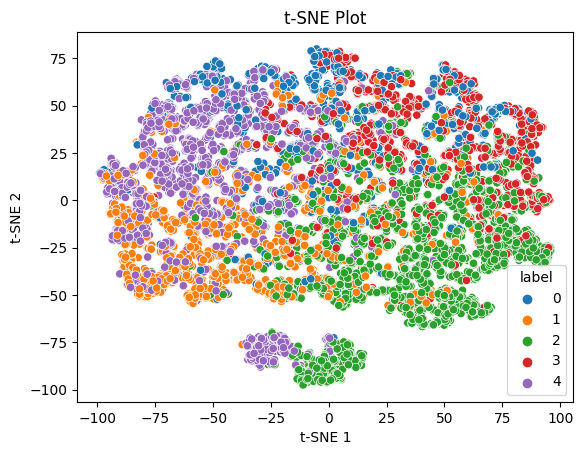

In [ ]:
#Obtain TSNE Plot of the dataset with the last model
plot_TSNE(train_loader, device, model)

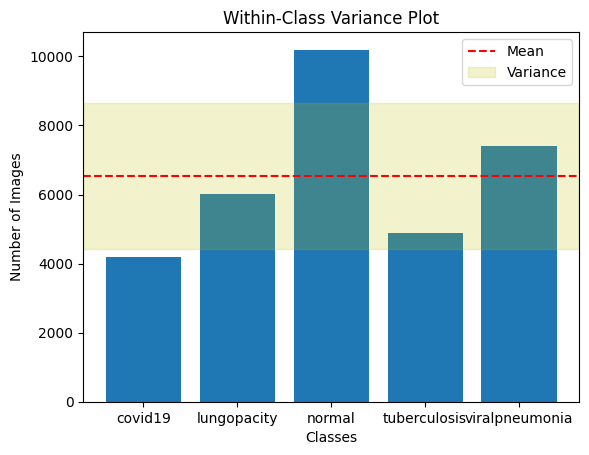

In [ ]:
# Get the Within Class Variance
plot_within_class_variance(dataset)